In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from statsmodels.tsa.api import VAR
from retrieve.get_data import get_yield

In [12]:
# ── Data ─────────────────────────────────────────────────────────────────────
term     = 5
duration = 5.0  # approximate modified duration for 5-year zero-coupon bond

raw_yields = get_yield(term, freq="W-FRI") / 100  # decimal (4.5% → 0.045)
dy         = raw_yields.diff().dropna()           # weekly yield changes

# weekly bond return: carry − duration × Δyield
carry     = raw_yields.shift(1).reindex(dy.index) / 52
bond_rets = carry - duration * dy

countries = bond_rets.columns.tolist()
n         = len(countries)

print(f"Assets ({n}): {countries}")
print(f"Date range: {bond_rets.index.min().date()} → {bond_rets.index.max().date()} ({len(bond_rets)} weeks)")

Assets (11): ['US', 'UK', 'FRA', 'GER', 'AUS', 'INDO', 'INDIA', 'JAPAN', 'SWITZ', 'BRAZIL', 'MEXICO']
Date range: 2012-02-03 → 2026-03-13 (737 weeks)


In [13]:
# ── Diebold-Yilmaz FEVD functions (from testing.ipynb) ───────────────────────
def generalized_fevd(var_results, H=10, normalize=True):
    names      = list(var_results.names)
    k          = len(names)
    Psi        = var_results.ma_rep(H)
    Sigma      = np.asarray(var_results.sigma_u)
    sigma_diag = np.diag(Sigma).copy()
    cum_numer  = np.zeros((k, k))
    cum_denom  = np.zeros(k)
    fevd       = np.zeros((H, k, k))
    for h in range(H):
        A           = Psi[h] @ Sigma
        cum_denom  += np.diag(A @ Psi[h].T)
        cum_numer  += A ** 2
        fevd[h]     = (cum_numer / sigma_diag) / cum_denom[:, None]
        if normalize:
            fevd[h] /= fevd[h].sum(axis=1, keepdims=True)
    return fevd, names


def spillover_table(fevd, names, H_index=-1):
    theta = fevd[H_index]
    k     = theta.shape[0]
    table = pd.DataFrame(theta * 100, index=names, columns=names)
    table["FROM_others"] = table.sum(axis=1) - np.diag(theta) * 100
    to_others            = table[names].sum(axis=0) - np.diag(theta) * 100
    table.loc["TO_others"] = list(to_others) + [np.nan]
    net                    = to_others.values - table.loc[table.index.isin(names), "FROM_others"].values
    table.loc["NET"]       = list(net) + [np.nan]
    tci                    = (theta.sum() - np.trace(theta)) / k * 100
    return table, tci

In [14]:
# ── Parameters ────────────────────────────────────────────────────────────────
roll_window        = 200    # rolling VAR window (weeks)
H_fevd             = 10     # FEVD horizon
alpha              = 1.0    # covariance inflation scale for connected pairs
starting_portfolio = 100_000.0
train_frac         = 0.70

In [15]:
# ── MV Optimizer: maximise Sharpe, long-only, fully invested ─────────────────
def mv_optimize(mu, Sigma):
    k  = len(mu)
    w0 = np.ones(k) / k

    def neg_sharpe(w):
        ret = float(w @ mu)
        vol = np.sqrt(max(float(w @ Sigma @ w), 1e-16))
        return -ret / vol

    res = minimize(
        neg_sharpe, w0,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * k,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
        options={"ftol": 1e-12, "maxiter": 1000},
    )
    return res.x if res.success else w0

In [16]:
# ── Train/test split ──────────────────────────────────────────────────────────
idx        = bond_rets.index
split_i    = int(np.floor(train_frac * len(idx)))
split_date = idx[split_i]
start_i    = max(split_i, roll_window + 1)

print(f"OOS start: {idx[start_i].date()}  |  OOS weeks: {len(idx) - start_i}")

OOS start: 2021-12-17  |  OOS weeks: 222


In [17]:
# ── Walk-forward loop ─────────────────────────────────────────────────────────
portfolio  = pd.Series(np.nan, index=idx)
weights_df = pd.DataFrame(np.nan, index=idx, columns=countries)
tci_series = pd.Series(np.nan, index=idx)
net_df     = pd.DataFrame(np.nan, index=idx, columns=countries)

portfolio.iloc[start_i] = starting_portfolio
w_eq = np.ones(n) / n   # equal-weight fallback

for i in range(start_i, len(idx) - 1):
    end_date  = idx[i]
    next_date = idx[i + 1]

    window_dy = dy.loc[:end_date].tail(roll_window).dropna()

    try:
        # VAR(1) on yield changes → generalized FEVD → spillover table
        var_res      = VAR(window_dy).fit(1)
        gfevd, names = generalized_fevd(var_res, H=H_fevd)
        spill, tci   = spillover_table(gfevd, names)
        tci_series.loc[end_date] = tci

        # pairwise spillover matrix — symmetric, values in [0, 1], diagonal zeroed
        theta    = gfevd[-1]
        pairwise = (theta + theta.T) / 2
        np.fill_diagonal(pairwise, 0.0)

        # reindex to match countries order
        name_idx = [names.index(c) for c in countries]
        pairwise = pairwise[np.ix_(name_idx, name_idx)]
        net_df.loc[end_date] = spill.loc["NET", names].reindex(countries).values.astype(float)

        # base covariance from rolling bond returns
        Sigma_base = bond_rets.loc[:end_date].tail(roll_window).cov().values

        # inflate off-diagonal covariances by spillover intensity — the only DY adjustment
        inflation = 1.0 + alpha * pairwise
        np.fill_diagonal(inflation, 1.0)
        Sigma_adj = Sigma_base * inflation

        # nearest PSD if needed
        min_eig = np.linalg.eigvalsh(Sigma_adj).min()
        if min_eig < 0:
            Sigma_adj += (-min_eig + 1e-8) * np.eye(n)

        # expected return = carry only, no penalty
        mu = raw_yields.loc[end_date].values / 52

        w = mv_optimize(mu, Sigma_adj)

    except Exception:
        w = w_eq

    weights_df.loc[end_date] = w
    r_next = bond_rets.loc[next_date].values
    portfolio.loc[next_date] = portfolio.loc[end_date] * (1.0 + float(w @ r_next))

portfolio = portfolio.ffill()
print("Done.")

Done.


In [18]:
# ── Equal-weight benchmark ────────────────────────────────────────────────────
ew_port = pd.Series(np.nan, index=idx)
ew_port.iloc[start_i] = starting_portfolio

for i in range(start_i, len(idx) - 1):
    r_next = bond_rets.loc[idx[i + 1]].values
    ew_port.iloc[i + 1] = ew_port.iloc[i] * (1.0 + float(w_eq @ r_next))

ew_port = ew_port.ffill()

In [19]:
# ── Performance metrics ───────────────────────────────────────────────────────
rf_weekly = raw_yields['US'].reindex(idx) / 52

def perf(port, label):
    p   = port.loc[split_date:].dropna()
    wr  = p.pct_change().dropna()
    rf  = rf_weekly.reindex(wr.index)
    ex  = wr - rf
    print(f"\n{'─'*45}")
    print(f"  {label}")
    print(f"{'─'*45}")
    print(f"  Test window:          {p.index.min().date()} → {p.index.max().date()}")
    print(f"  Total return:         {p.iloc[-1]/p.iloc[0]-1:.2%}")
    print(f"  Ann. Sharpe (gross):  {(wr.mean()/wr.std(ddof=0))*np.sqrt(52):.2f}")
    print(f"  Ann. Sharpe (excess): {(ex.mean()/ex.std(ddof=0))*np.sqrt(52):.2f}")
    print(f"  Ann. Vol:             {wr.std(ddof=0)*np.sqrt(52):.2%}")
    print(f"  Max drawdown:         {((p-p.cummax())/p.cummax()).min():.2%}")
    print(f"  Hit rate:             {(wr>0).mean():.1%}")

perf(portfolio, "DY Spillover-Adjusted MV")
perf(ew_port,   "Equal-Weight Benchmark")


─────────────────────────────────────────────
  DY Spillover-Adjusted MV
─────────────────────────────────────────────
  Test window:          2021-12-17 → 2026-03-13
  Total return:         30.12%
  Ann. Sharpe (gross):  1.89
  Ann. Sharpe (excess): 0.76
  Ann. Vol:             3.30%
  Max drawdown:         -5.32%
  Hit rate:             63.8%

─────────────────────────────────────────────
  Equal-Weight Benchmark
─────────────────────────────────────────────
  Test window:          2021-12-17 → 2026-03-13
  Total return:         8.95%
  Ann. Sharpe (gross):  0.60
  Ann. Sharpe (excess): -0.49
  Ann. Vol:             3.46%
  Max drawdown:         -7.51%
  Hit rate:             53.8%


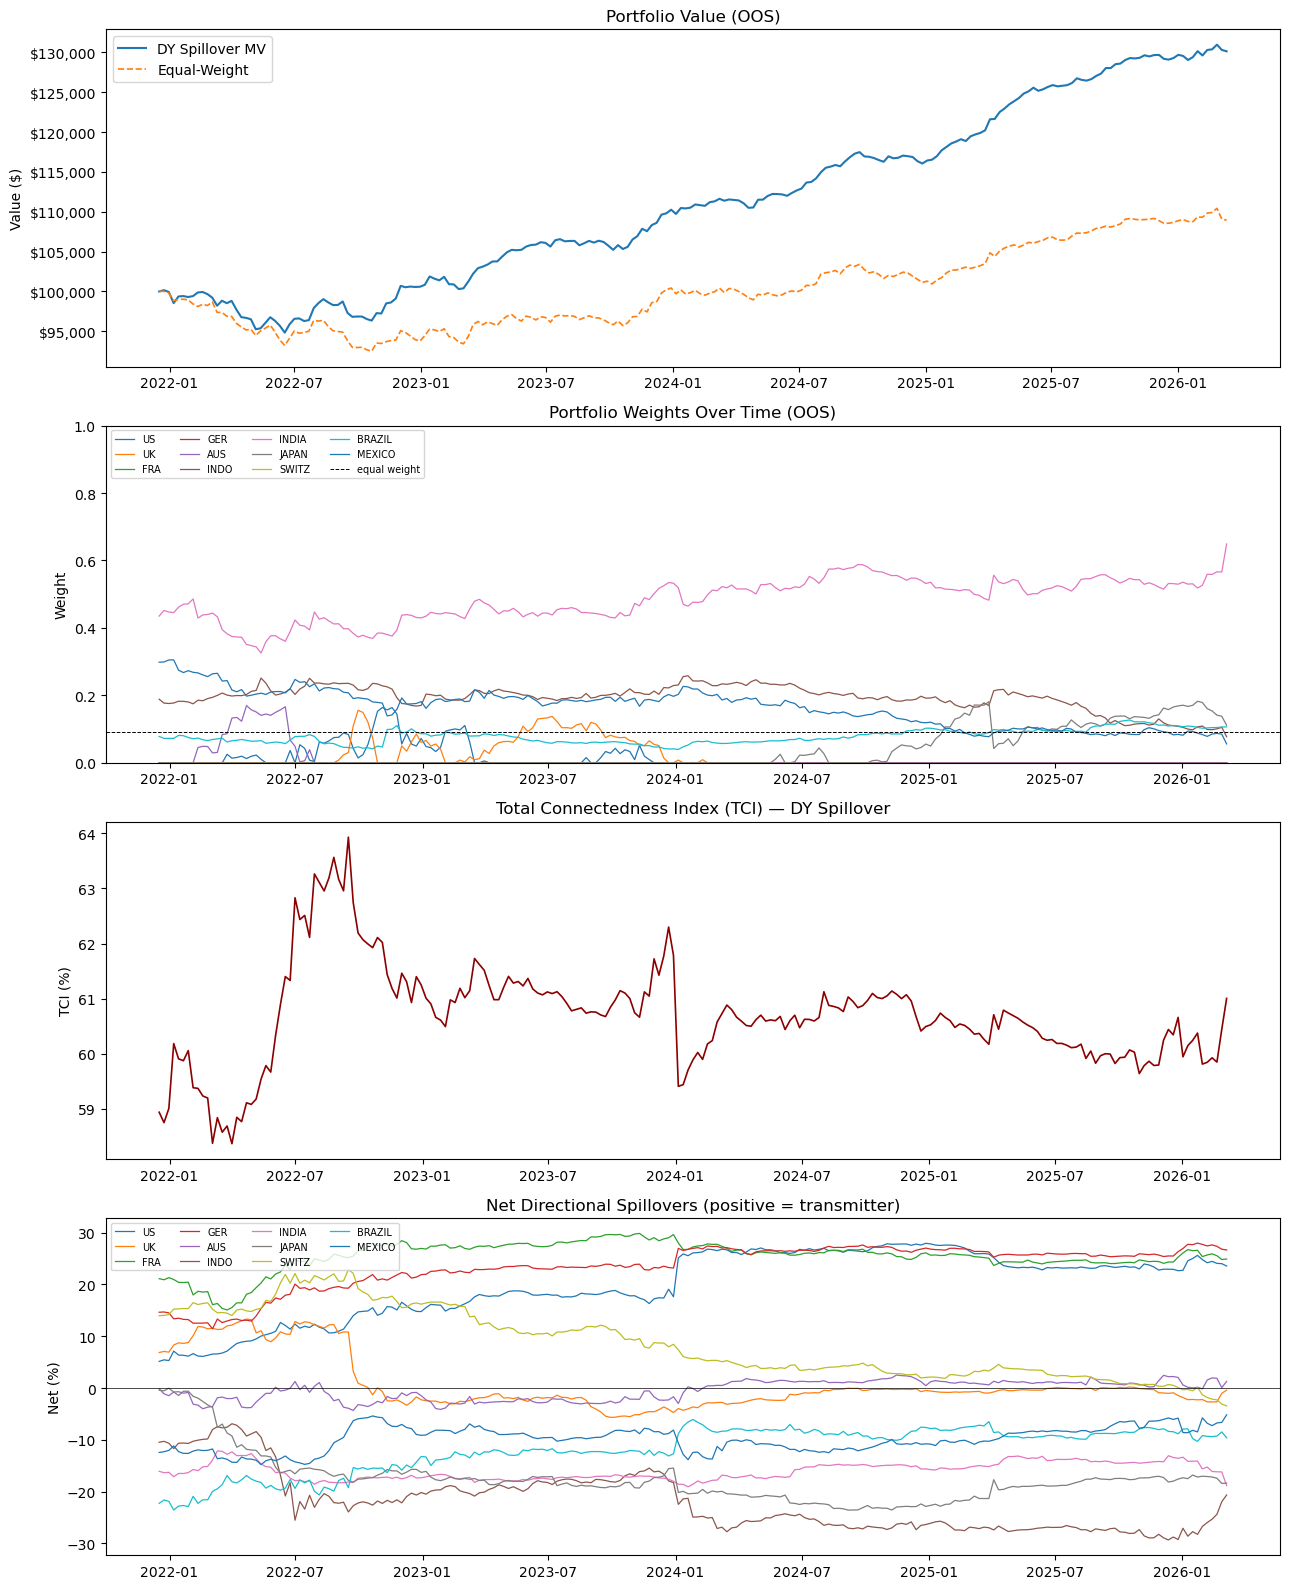

In [20]:
# ── Plots ─────────────────────────────────────────────────────────────────────
w_oos   = weights_df.loc[split_date:].dropna(how='all').astype(float)
tci_oos = tci_series.loc[split_date:].dropna()

fig, axes = plt.subplots(4, 1, figsize=(13, 16))

# 1. Portfolio value vs benchmark
port_oos = portfolio.loc[split_date:].dropna()
ew_oos   = ew_port.loc[split_date:].dropna()
axes[0].plot(port_oos.index, port_oos.values, lw=1.5, label="DY Spillover MV")
axes[0].plot(ew_oos.index,   ew_oos.values,   lw=1.2, ls='--', label="Equal-Weight")
axes[0].set_title("Portfolio Value (OOS)")
axes[0].set_ylabel("Value ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# 2. Weights over time
for col in countries:
    axes[1].plot(w_oos.index, w_oos[col], lw=0.9, label=col)
axes[1].axhline(1/n, color='black', ls='--', lw=0.7, label='equal weight')
axes[1].set_ylim(0, 1)
axes[1].set_title("Portfolio Weights Over Time (OOS)")
axes[1].set_ylabel("Weight")
axes[1].legend(ncol=4, fontsize=7, loc='upper left')

# 3. Total Connectedness Index
axes[2].plot(tci_oos.index, tci_oos.values, lw=1.2, color='darkred')
axes[2].set_title("Total Connectedness Index (TCI) — DY Spillover")
axes[2].set_ylabel("TCI (%)")

# 4. Net spillovers over time
net_oos = net_df.loc[split_date:].dropna(how='all').astype(float)
for col in countries:
    axes[3].plot(net_oos.index, net_oos[col], lw=0.9, label=col)
axes[3].axhline(0, color='black', lw=0.5)
axes[3].set_title("Net Directional Spillovers (positive = transmitter)")
axes[3].set_ylabel("Net (%)")
axes[3].legend(ncol=4, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()